# ModelSentry Quickstart

Neste notebook vamos simular o uso básico da biblioteca ModelSentry para montar uma suíte de validação de modelos.

In [9]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt

# Ajuste para que o notebook enxergue o pacote source se rodar local
sys.path.insert(0, os.path.abspath('../src'))

from modelsentry.core.suite import ValidationSuite
from modelsentry.dimensions.quantitative.stability import PSI_KRI
from modelsentry.dimensions.quantitative.performance import AUCROC_KRI
from modelsentry.dimensions.qualitative.data_quality import MissingValuesKRI

from modelsentry.io.writer import save_summary_to_sqlite, save_artifacts_to_sqlite
from modelsentry.viz.plots import plot_kri_summary, plot_psi_mensal

# Prepara para os gráficos renderizarem inline no notebook
%matplotlib inline

## 1. Carregando Dados (Simulados)

Geralmente você utilizará dados conectando no SQLite ou outro banco (ex: lendo saídas reais de predição). Aqui usaremos um dataframe dummy com formato base.

In [10]:
df_simulado = pd.DataFrame({
    'idade': [25, 30, 45, 22],
    'renda': [2000, 4000, None, 1500],
    'amostra': ['dev', 'dev', 'oot', 'oot'],
    'target': [1, 0, 1, 0],
    'score': [0.9, 0.2, 0.8, 0.3],
    'data_ref': ['2023-01-01', '2023-02-01', '2024-01-01', '2024-02-01']
})
display(df_simulado)

,idade,renda,amostra,target,score,data_ref
0,25,2000.0,dev,1,0.9,2023-01-01
1,30,4000.0,dev,0,0.2,2023-02-01
2,45,NaN,oot,1,0.8,2024-01-01
3,22,1500.0,oot,0,0.3,2024-02-01


## 2. Inicializando a Suite

Informamos onde estão as colunas chave.

In [11]:
suite = ValidationSuite(
    df=df_simulado,
    date_col='data_ref',
    sample_col='amostra',
    target_col='target',
    score_col='score',
    features=['idade', 'renda']
)

## 3. Adicionando os Indicadores (KRIs)

Você pode regular os parâmetros de cada KRI para ditar quão tolerante você quer ser.

In [12]:
suite.add_test(MissingValuesKRI(fail_threshold=0.15))
suite.add_test(AUCROC_KRI(min_passed=0.80))
suite.add_test(PSI_KRI(ref_sample='dev', eval_samples=['oot']))

## 4. Executando e Avaliando o Risco

Rodando a suite obtemos a lista de `ValidationResult`s, contendo a tradução dos números obtidos para `risk_score` e `risk_level`.

In [13]:
resultados = suite.run()

print("======= RELATÓRIO DO MODELSENTRY =======")
for r in resultados:
    print(f"\n📝 Teste: {r.name}")
    print(f"   Valor Base: {r.value}")
    print(f"   Risk Score (0 a 100): {r.risk_score}")
    print(f"   Nível de Risco: {r.risk_level}")
print("========================================")

global_risk = suite.calculate_global_risk(resultados)
print(f"\n🌍 Risco Global Hierárquico: {global_risk:.2f}")

======= RELATÓRIO DO MODELSENTRY =======

📝 Teste: Missing Values KRI
   Valor Base: 0.02
   Risk Score (0 a 100): 16.0
   Nível de Risco: Muito Baixo

📝 Teste: AUC-ROC KRI
   Valor Base: 0.75
   Risk Score (0 a 100): 90.0
   Nível de Risco: Crítico

📝 Teste: Population Stability Index (PSI) KRI
   Valor Base: 1772.4909090716937
   Risk Score (0 a 100): 100.0
   Nível de Risco: Crítico

🌍 Risco Global Hierárquico: 55.50


## 5. Visualização (Suporte Viz)

Usando o módulo auxiliar, podemos renderizar o mapa de Risco e explorar tabelas intermediárias como as caixas do PSI.

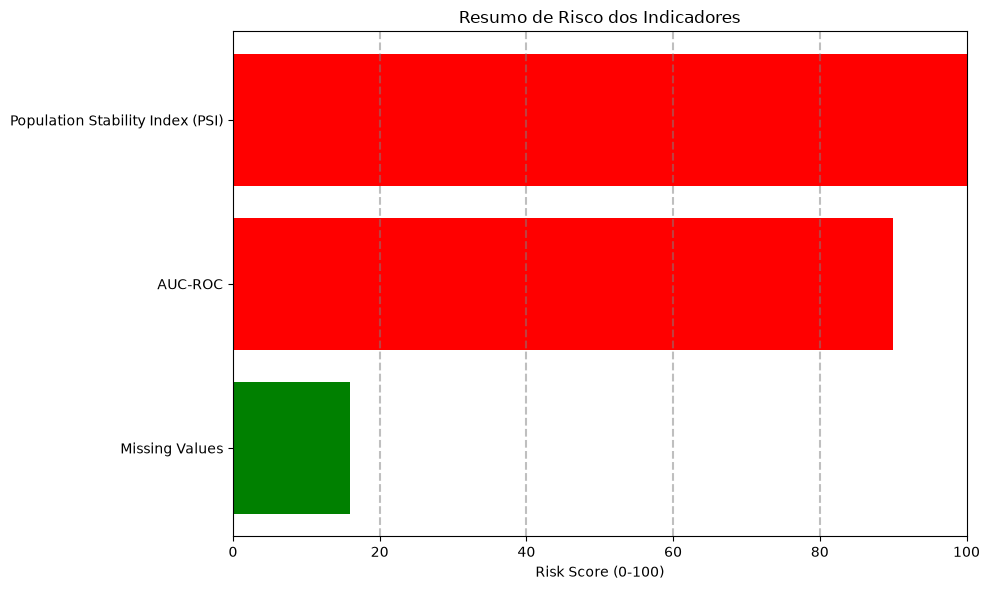

In [14]:
fig_summary = plot_kri_summary(resultados)
plt.show()

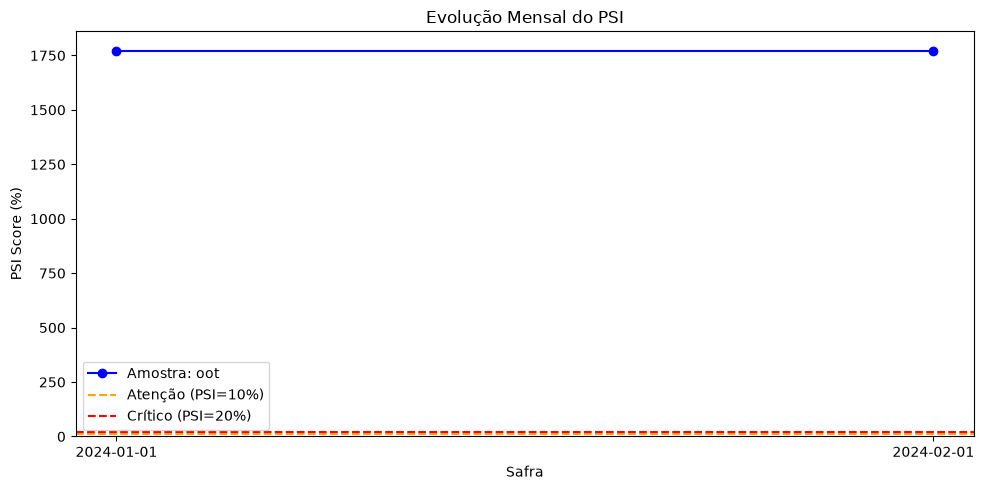

In [15]:
# O 3º teste inserido (índice 2) é o PSI.
fig_psi = plot_psi_mensal(resultados[2])
plt.show()

## 6. Persistência de Dados (Suporte I/O)

Ao fim da rotina, basta acionar os escritores auxiliares para persistir os resultados brutos em um banco relacional como o SQLite.

In [16]:
DB_PATH = "resultados_modelsentry.db"

# Salva o consolidado (Risk Score e Level)
save_summary_to_sqlite(resultados, DB_PATH)

# Salva as tabelas intermediárias de cálculo (ex: psi_bins)
save_artifacts_to_sqlite(resultados, DB_PATH)

print(f"✅ Resultados e artefatos foram salvos no banco SQLite: {DB_PATH}")

✅ Resultados e artefatos foram salvos no banco SQLite: resultados_modelsentry.db
